# OIBSIP Task 1 — Exploratory Data Analysis on Retail Sales Data

**Track:** Data Analytics  
**Internship:** Oasis Infobyte  
**Task:** EDA on Retail Sales Data

## Objective

The objective of this project is to explore retail sales data using Python and identify
sales trends, high-performing products, revenue patterns, promotional effects, and
relationships between numerical variables.

## 1. Import Libraries and Load Dataset

In [6]:
import pandas as pd

df = pd.read_csv("/numerical_retail_sales.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (3767338, 2)


023   6
9 37 62 71.90 0 1 3  2023   7
     60 71.90 0 2 3  2023   8
     56 71.90 0 3 3  2023   9
     72 57.52 1 4 3  2023  10
     43 71.90 0 5 3  2023  11

In [7]:
print("Number of columns:", len(df.columns))
print("Column names:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
print(df.head(3).to_string())

Number of columns: 2
Column names:
['023', '6']

First 3 rows:
                     023  6
9 37 62 71.9 0 1 3  2023  7
     60 71.9 0 2 3  2023  8
     56 71.9 0 3 3  2023  9


In [8]:
with open("/numerical_retail_sales.csv", "r") as f:
    for i in range(5):
        print(repr(f.readline()))



'023,6\n'
'9,37,62,71.9,0,1,3,2023,7\n'
'9,37,60,71.9,0,2,3,2023,8\n'
'9,37,56,71.9,0,3,3,2023,9\n'
'9,37,72,57.52,1,4,3,2023,10\n'


In [9]:
import pandas as pd

# Load CSV without using the incorrect first row as the header
df = pd.read_csv(
    "/numerical_retail_sales.csv",
    header=None,
    skiprows=1
)

# Give meaningful column names
df.columns = [
    "store_id",
    "item_id",
    "sales",
    "price",
    "promo",
    "weekday",
    "month",
    "year",
    "day"
]

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (3767338, 9)


,store_id,item_id,sales,price,promo,weekday,month,year,day
0,9,37,62,71.90,0,1,3,2023,7
1,9,37,60,71.90,0,2,3,2023,8
2,9,37,56,71.90,0,3,3,2023,9
3,9,37,72,57.52,1,4,3,2023,10
4,9,37,43,71.90,0,5,3,2023,11


In [11]:
# Check data types and missing values

print("DATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

print("\nSTATISTICAL SUMMARY")
display(df.describe())

DATA TYPES
store_id      int64
item_id       int64
sales         int64
price       float64
promo         int64
weekday       int64
month         int64
year          int64
day           int64
dtype: object

MISSING VALUES
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
year        0
day         0
dtype: int64

DUPLICATE ROWS
0

STATISTICAL SUMMARY


,store_id,item_id,sales,price,promo,weekday,month,year,day
count,3.767338e+06,3.767338e+06,3.767338e+06,3.767338e+06,3.767338e+06,3.767338e+06,3.767338e+06,3.767338e+06,3.767338e+06
mean,2.986601e+01,2.561748e+01,2.913955e+01,5.408063e+01,9.995413e-02,3.001644e+00,6.523634e+00,2.021000e+03,1.572785e+01
std,1.191229e+01,1.446246e+01,1.491918e+01,2.565250e+01,2.999389e-01,1.999315e+00,3.448502e+00,1.414076e+00,8.799322e+00
min,9.000000e+00,1.000000e+00,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.019000e+03,1.000000e+00
25%,2.000000e+01,1.300000e+01,1.800000e+01,3.251000e+01,0.000000e+00,1.000000e+00,4.000000e+00,2.020000e+03,8.000000e+00
50%,3.000000e+01,2.600000e+01,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00,2.021000e+03,1.600000e+01
75%,4.000000e+01,3.800000e+01,3.800000e+01,7.532000e+01,0.000000e+00,5.000000e+00,1.000000e+01,2.022000e+03,2.300000e+01
max,5.000000e+01,5.000000e+01,1.390000e+02,9.989000e+01,1.000000e+00,6.000000e+00,1.200000e+01,2.023000e+03,3.100000e+01


In [12]:
# Create a proper date column
df["date"] = pd.to_datetime(
    df[["year", "month", "day"]]
)

# Calculate revenue
df["revenue"] = df["sales"] * df["price"]

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nNumber of stores:", df["store_id"].nunique())
print("Number of items:", df["item_id"].nunique())

print("\nTotal units sold:", df["sales"].sum())
print("Total revenue:", df["revenue"].sum())

display(df[["date", "store_id", "item_id", "sales", "price", "promo", "revenue"]].head())

Date range:
2019-01-01 00:00:00 to 2023-12-31 00:00:00

Number of stores: 42
Number of items: 50

Total units sold: 109778526
Total revenue: 5844023401.870011


,date,store_id,item_id,sales,price,promo,revenue
0,2023-03-07,9,37,62,71.90,0,4457.80
1,2023-03-08,9,37,60,71.90,0,4314.00
2,2023-03-09,9,37,56,71.90,0,4026.40
3,2023-03-10,9,37,72,57.52,1,4141.44
4,2023-03-11,9,37,43,71.90,0,3091.70


In [13]:
# Calculate monthly sales

monthly_sales = (
    df.groupby(df["date"].dt.to_period("M"))["sales"]
      .sum()
      .reset_index()
)

monthly_sales["date"] = monthly_sales["date"].astype(str)

display(monthly_sales.head())

,date,sales
0,2019-01,1788968
1,2019-02,1789124
2,2019-03,2083184
3,2019-04,2065914
4,2019-05,2026157


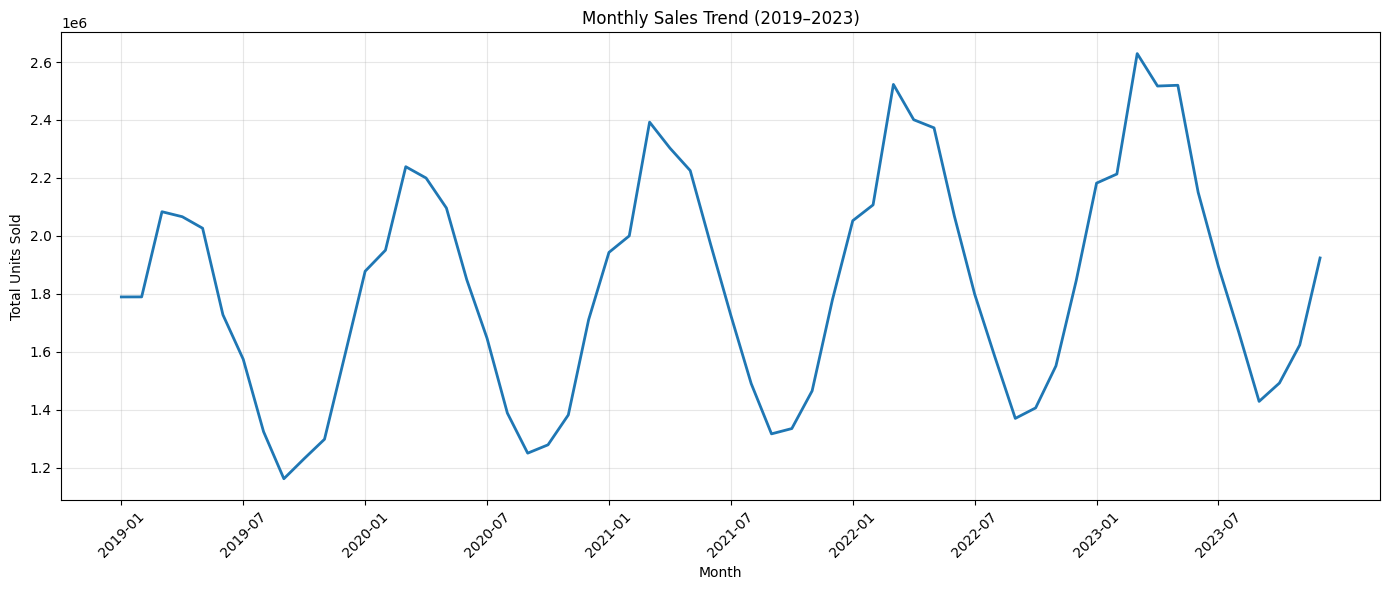

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["date"],
    monthly_sales["sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend (2019–2023)")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")

plt.xticks(
    monthly_sales["date"][::6],
    rotation=45
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Create quarter column
df["quarter"] = df["date"].dt.quarter

# Calculate quarterly sales
quarterly_sales = (
    df.groupby(["year", "quarter"])["sales"]
      .sum()
      .reset_index()
)

display(quarterly_sales)

,year,quarter,sales
0,2019,1,5661276
1,2019,2,5819404
2,2019,3,4058897
3,2019,4,4115498
4,2020,1,6066649
5,2020,2,6144194
6,2020,3,4283807
7,2020,4,4370490
8,2021,1,6335033
9,2021,2,6499745


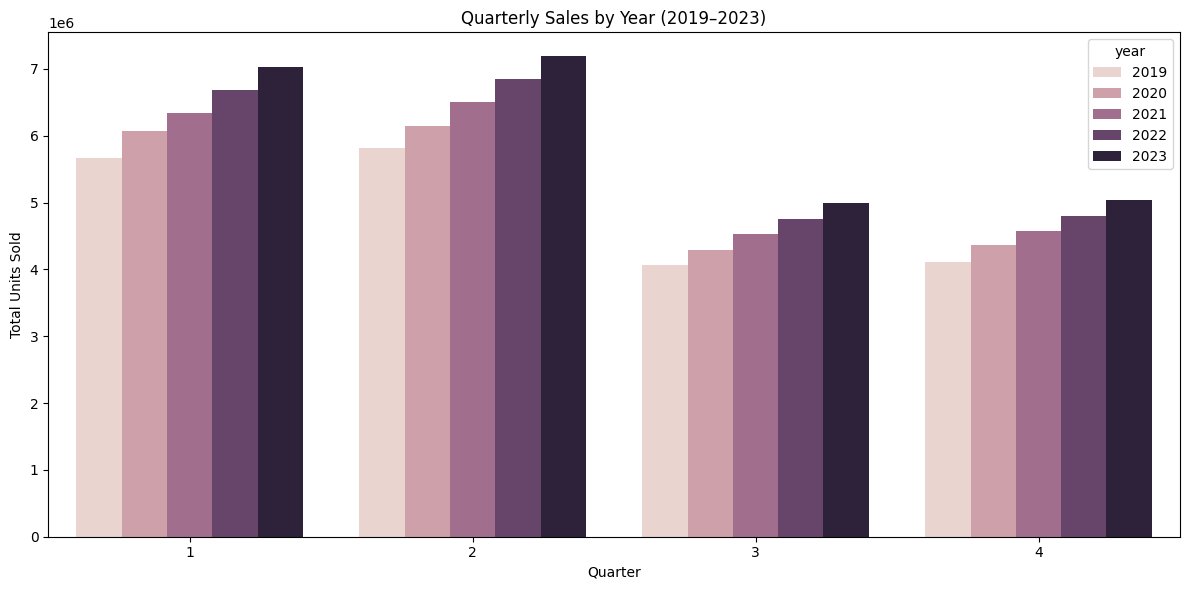

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=quarterly_sales,
    x="quarter",
    y="sales",
    hue="year"
)

plt.title("Quarterly Sales by Year (2019–2023)")
plt.xlabel("Quarter")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [17]:
# Top 10 products by total units sold

top_products = (
    df.groupby("item_id")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

print("Top 10 Products by Total Sales:")
display(top_products)

Top 10 Products by Total Sales:


,item_id,sales
0,20,3478118
1,1,3432149
2,3,3352637
3,6,3304918
4,39,3298284
5,4,3236520
6,31,3151517
7,13,3062046
8,24,3029717
9,18,2991549


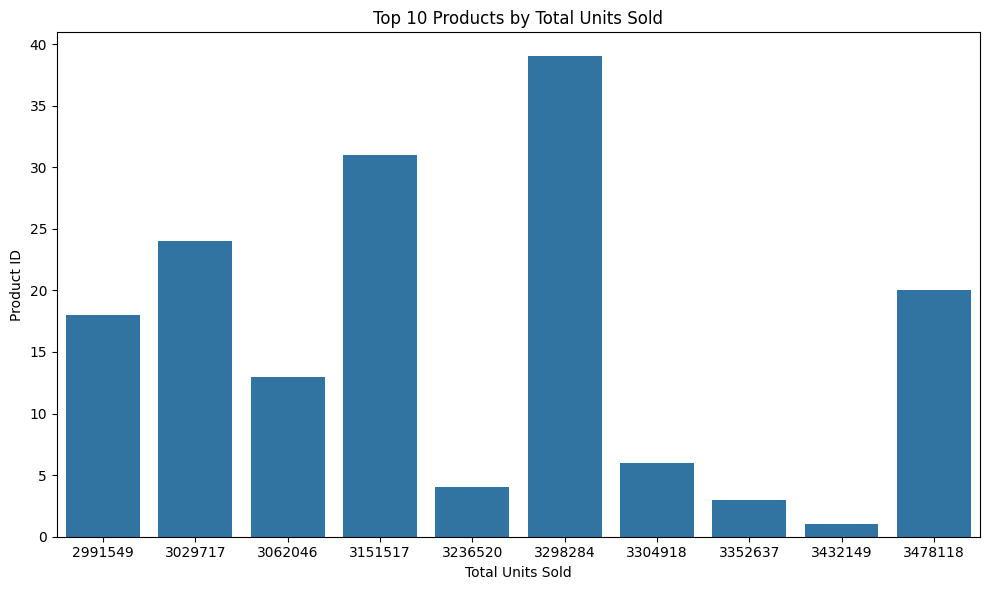

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products,
    x="sales",
    y="item_id"
)

plt.title("Top 10 Products by Total Units Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()

In [19]:
# Top 10 products by revenue

top_revenue_products = (
    df.groupby("item_id")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

print("Top 10 Products by Revenue:")
display(top_revenue_products)

Top 10 Products by Revenue:


,item_id,revenue
0,20,1.909058e+08
1,1,1.899569e+08
2,39,1.890608e+08
3,4,1.861801e+08
4,31,1.728129e+08
5,6,1.700617e+08
6,13,1.675898e+08
7,3,1.673592e+08
8,2,1.633002e+08
9,43,1.624977e+08


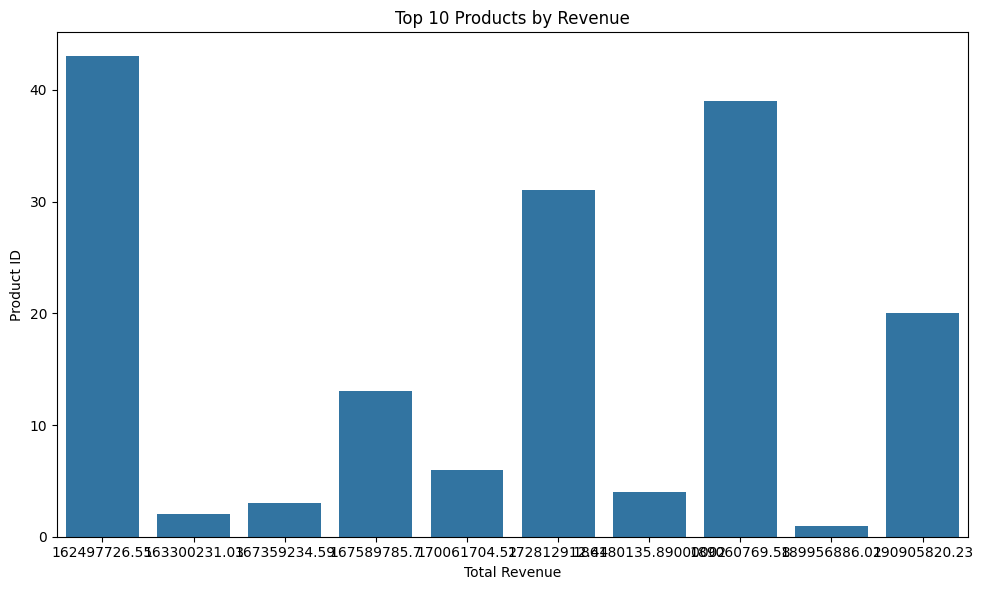

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_revenue_products,
    x="revenue",
    y="item_id"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()

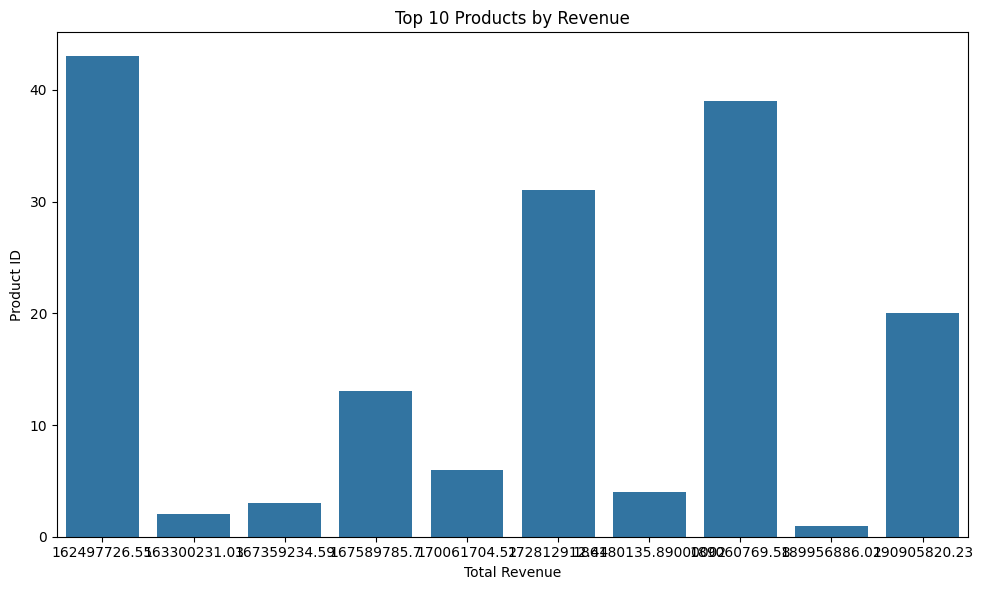

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_revenue_products,
    x="revenue",
    y="item_id"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()

In [22]:
# Promotion analysis

promo_analysis = (
    df.groupby("promo")
      .agg(
          total_sales=("sales", "sum"),
          average_sales=("sales", "mean"),
          total_revenue=("revenue", "sum"),
          records=("sales", "count")
      )
      .reset_index()
)

display(promo_analysis)

,promo,total_sales,average_sales,total_revenue,records
0,0,94085784,27.747559,5.155336e+09,3390777
1,1,15692742,41.673838,6.886870e+08,376561


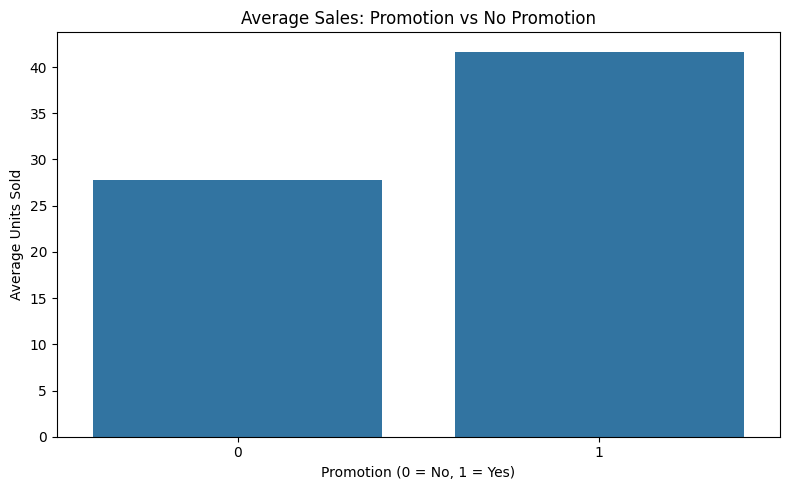

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=promo_analysis,
    x="promo",
    y="average_sales"
)

plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

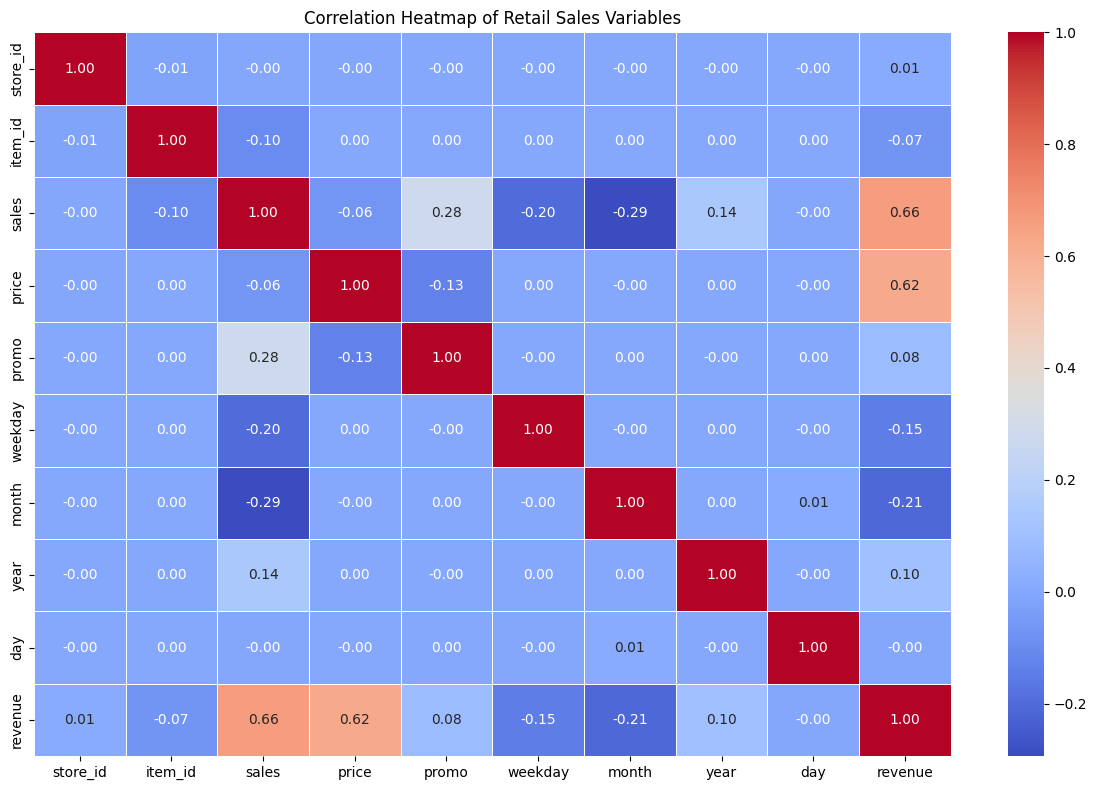

In [24]:
# Correlation analysis

correlation_data = df[
    [
        "store_id",
        "item_id",
        "sales",
        "price",
        "promo",
        "weekday",
        "month",
        "year",
        "day",
        "revenue"
    ]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Retail Sales Variables")
plt.tight_layout()
plt.show()

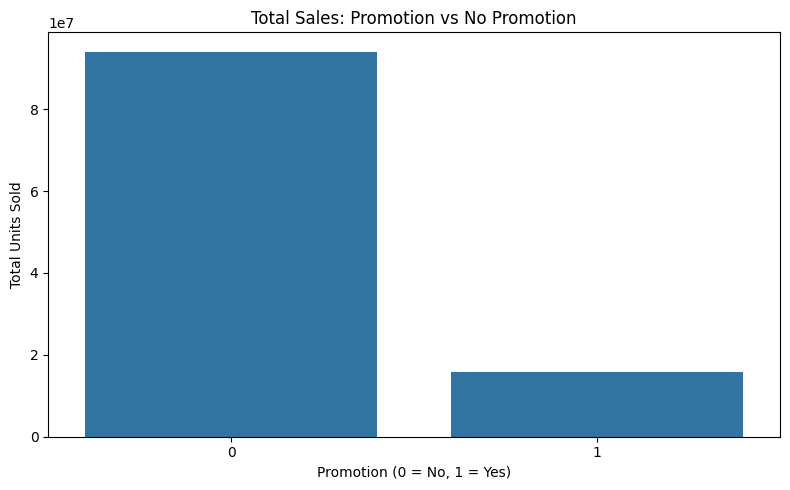

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=promo_analysis,
    x="promo",
    y="total_sales"
)

plt.title("Total Sales: Promotion vs No Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

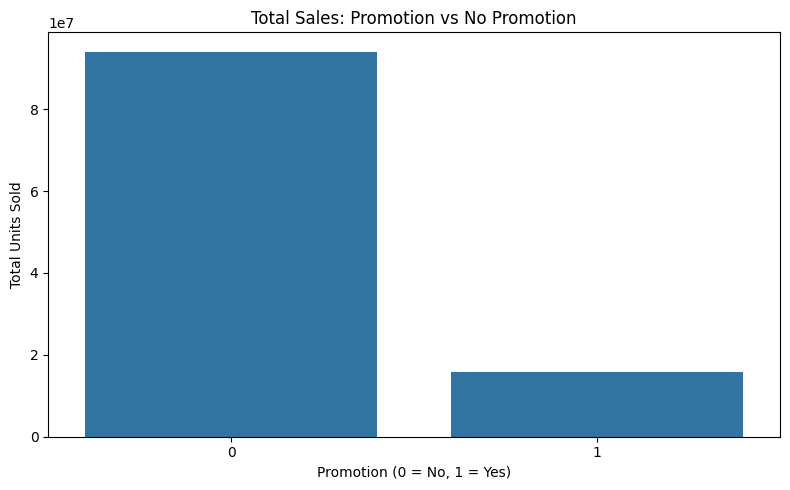

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=promo_analysis,
    x="promo",
    y="total_sales"
)

plt.title("Total Sales: Promotion vs No Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [27]:
# Key business metrics

best_month = (
    df.groupby(df["date"].dt.to_period("M"))["sales"]
      .sum()
      .idxmax()
)

best_month_sales = (
    df.groupby(df["date"].dt.to_period("M"))["sales"]
      .sum()
      .max()
)

best_quarter = quarterly_sales.loc[
    quarterly_sales["sales"].idxmax()
]

best_product = top_products.iloc[0]

best_revenue_product = top_revenue_products.iloc[0]

print("KEY FINDINGS")
print("-" * 50)

print(f"Highest-selling month: {best_month}")
print(f"Sales in that month: {best_month_sales:,} units")

print(
    f"\nHighest-selling quarter: "
    f"{int(best_quarter['year'])} Q{int(best_quarter['quarter'])}"
)
print(f"Quarterly sales: {best_quarter['sales']:,} units")

print(
    f"\nTop product by units: Item {int(best_product['item_id'])}"
)
print(f"Units sold: {best_product['sales']:,}")

print(
    f"\nTop product by revenue: Item {int(best_revenue_product['item_id'])}"
)
print(f"Revenue: ₹{best_revenue_product['revenue']:,.2f}")

KEY FINDINGS
--------------------------------------------------
Highest-selling month: 2023-03
Sales in that month: 2,629,132 units

Highest-selling quarter: 2023 Q2
Quarterly sales: 7,186,931 units

Top product by units: Item 20
Units sold: 3,478,118

Top product by revenue: Item 20
Revenue: ₹190,905,820.23


### Business Recommendations

1. **Improve inventory planning:**  
   Prepare inventory and staffing for periods with consistently higher sales,
   particularly Q1 and Q2.

2. **Prioritize high-performing products:**  
   Item 20 generated the highest total units sold and revenue in this dataset.
   Inventory levels for high-performing items should be monitored carefully.

3. **Use promotions strategically:**  
   Promotional performance should be compared with non-promotional periods
   to identify products and periods where promotions generate measurable
   improvements in sales.